<a href="https://colab.research.google.com/github/harshit-538/ML-DL/blob/main/3_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gradient Descent**

- It is used mainly used to calculate weight&bias in logistic regression.
- calculates log loss/entropy and then update weights&bias in each epoch.(Back-propogate)
- Learning rate(generally 0.01) it helps to control change in log loss error.
- after each epoch, calculate derivative of log loss with respoct to all weights and bias and update it.

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import seaborn as sn
import pandas as pd

In [ ]:
# Creating own Dataset

age = np.array([22,25,47,52,46,56,55,60,62,61,18,28,27,29,49,55,25,58,19,18,21,26,40,45,50,54,23,38])

affordibility = np.array([1,0,1,0,1,1,0,0,1,1,1,1,0,0,1,1,0,1,0,1,1,0,1,1,1,1,1,1])

bought_insurance = np.array([0,0,1,0,1,1,0,1,1,1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,1,0,0])

In [ ]:
df = np.column_stack((age,affordibility,bought_insurance))

In [ ]:
df = pd.DataFrame(df,columns=['age','affordibility','bought_insurance'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df[['age','affordibility']],df.bought_insurance,test_size=0.2,random_state=25)

In [ ]:
x_train_sclaed = X_train.copy()
x_train_sclaed['age'] = x_train_sclaed['age']/100

x_test_sclaed = X_test.copy()
x_test_sclaed['age'] = x_test_sclaed['age']/100

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(1,input_shape=(2,),activation='sigmoid',kernel_initializer='ones',bias_initializer='zeros')
])

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

model.fit(x_train_sclaed,y_train,epochs=5000)

Epoch 1/5000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Streaming output truncated to the last 5000 lines.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7727 - loss: 0.5226
Epoch 2502/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7727 - loss: 0.5226
Epoch 2503/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7727 - loss: 0.5225
Epoch 2504/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7727 - loss: 0.5225
Epoch 2505/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7727 - loss: 0.5225
Epoch 2506/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7727 - loss: 0.5224
Epoch 2507/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7727 - loss: 0.5224
Epoch 2508/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7727 - loss: 0.5223
Epoch 2509/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7727 - loss: 0.5223
Epoch 2510/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.7727 - loss: 0.5223
Epoch 2511/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.7727 - lo

In [ ]:
model.evaluate(x_test_sclaed,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 1.0000 - loss: 0.3496


[0.3495520055294037, 1.0]

In [ ]:
y_pred = model.predict(x_test_sclaed)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([[0.71448576],
       [0.3552302 ],
       [0.16644086],
       [0.4814421 ],
       [0.7352926 ],
       [0.8386039 ]], dtype=float32)

In [ ]:
coef,intercept = model.get_weights()
coef,intercept

(array([[5.2186155],
        [1.4324265]], dtype=float32),
 array([-2.9679046], dtype=float32))

use this coef and intercept from above


In [ ]:
import math
def sigmoid(x):
  return 1/(1 + math.exp(-x));

In [ ]:
def prediction_function(age,affordibility):
  weighted_sum = coef[0]*age + coef[1]*affordibility + intercept
  return sigmoid(weighted_sum)

In [ ]:
prediction_function(.47,1)

/tmp/ipython-input-3403181760.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1/(1 + math.exp(-x));


0.7144857549709942

# **From Scratch**

In [ ]:
def log_loss(y_true,y_pred):
  epsilon = 1e-15
  y_pred_new = [max(i,epsilon) for i in y_pred]
  y_pred_new = [min(i,i-epsilon) for i in y_pred_new]
  y_pred_new = np.array(y_pred_new)
  return -np.mean(y_true*np.log(y_pred_new)+(1-y_true)*np.log(1-y_pred_new))

In [ ]:
def sigmoid_numpy(x):
  return 1/(1+np.exp(-x))

In [ ]:
def gradient_descent(age,affordibility,y_true,epochs,threshold):
# it will return both coef and intercept
#This is just a function
  w1 = w2 = 1
  bias = 0
  rate = 0.5
  n = len(age)

  for i in range(epochs):
    weighted_sum = w1*age + w2*affordibility + bias
    y_pred = sigmoid_numpy(weighted_sum)

    loss = log_loss(y_true,y_pred)

    w1d = (1/n)*np.dot(np.transpose(age),(y_pred-y_true))
    w2d = (1/n)*np.dot(np.transpose(affordibility),(y_pred-y_true))

    bias_d = np.mean(y_pred - y_true)

    w1 = w1 - rate * w1d
    w2 = w2 - rate * w2d
    bias = bias - rate * bias_d

    print(f'Epoch:{i}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}')

    if loss <= threshold:
      break

  return w1,w2,bias

In [ ]:
gradient_descent(x_train_sclaed['age'],x_train_sclaed['affordibility'],y_train,1000,0.4478)

Epoch:0, w1:0.9764914618862416, w2:0.9486331634521814, bias:-0.11313363930603333, loss:0.7084119128672071
Epoch:1, w1:0.9587026062366529, w2:0.9064130297174073, bias:-0.21174749413961003, loss:0.6786492072768174
Epoch:2, w1:0.946138713965328, w2:0.8726954052393727, bias:-0.2971520851994073, loss:0.6567392473954858
Epoch:3, w1:0.9382128977970783, w2:0.8466114305727271, bias:-0.3708639732681127, loss:0.6408666009607964
Epoch:4, w1:0.934309497124362, w2:0.8271890796951613, bias:-0.4344506647932769, loss:0.6294602516280402
Epoch:5, w1:0.9338314592222037, w2:0.8134495278910242, bias:-0.4894173390311499, loss:0.621258076714085
Epoch:6, w1:0.9362298786625239, w2:0.8044711793619568, bias:-0.5371381580451271, loss:0.6153012104735784
Epoch:7, w1:0.9410185713035398, w2:0.7994248197480652, bias:-0.5788240654287733, loss:0.6108908954225932
Epoch:8, w1:0.9477780991902104, w2:0.797587513217716, bias:-0.615515802880086, loss:0.6075333425347076
Epoch:9, w1:0.9561533285626389, w2:0.798342887708055, bias

(np.float64(5.205470296227018),
 np.float64(1.476759504742452),
 np.float64(-3.009889729264041))

## **Bilding own NN class from scratch**

In [ ]:
class myNN:
  def __init__(self):
    self.w1 = 1
    self.w1 = 1
    self.bias = 0

  def fit(self,X,y,epochs,threshold):
      self.w1,self.w2,self.bias = self.gradient_descent(X['age'],X['affordibility'],y,epochs,threshold)

  def predict(self,x_test):
    weighted_sum = self.w1*x_test['age'] + self.w2*x_test['affordibility'] + self.bias
    return sigmoid_numpy(weighted_sum)

  def gradient_descent(self,age,affordibility,y_true,epochs,threshold):
    w1 = w2 = 1
    bias = 0
    rate = 0.5
    n = len(age)

    for i in range(epochs):
      weighted_sum = w1*age + w2*affordibility + bias
      y_pred = sigmoid_numpy(weighted_sum)

      loss = log_loss(y_true,y_pred)

      w1d = (1/n)*np.dot(np.transpose(age),(y_pred-y_true))
      w2d = (1/n)*np.dot(np.transpose(affordibility),(y_pred-y_true))

      bias_d = np.mean(y_pred - y_true)

      w1 = w1 - rate * w1d
      w2 = w2 - rate * w2d
      bias = bias - rate * bias_d

      if i%50==0:
        print(f'Epoch:{i}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}')

      if loss <= threshold:
        print(f'Epoch:{i}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}')
        break

    return w1,w2,bias


In [ ]:
customModel = myNN()
customModel.fit(x_train_sclaed,y_train,500,0.4478)

Epoch:0, w1:0.9764914618862416, w2:0.9486331634521814, bias:-0.11313363930603333, loss:0.7084119128672071
Epoch:50, w1:1.5543768448783088, w2:1.1079664764667208, bias:-1.2438154323605612, loss:0.5624280981569784
Epoch:100, w1:2.2946721762280653, w2:1.2949009846832376, bias:-1.6875625049599523, loss:0.5308976331574279
Epoch:150, w1:2.9826320797682793, w2:1.3734866386379347, bias:-2.027901246054411, loss:0.506960649396159
Epoch:200, w1:3.611838443621567, w2:1.4121826390929748, bias:-2.313493980341203, loss:0.48772332203726126
Epoch:250, w1:4.184232705519198, w2:1.4366520198791268, bias:-2.5647778482396504, loss:0.47200888302411775
Epoch:300, w1:4.704607157517727, w2:1.4566172153879893, bias:-2.791281592775389, loss:0.4590626281506298
Epoch:350, w1:5.178406748455552, w2:1.4756189024683144, bias:-2.9980392174351524, loss:0.4483217958287263
Epoch:353, w1:5.205470296227018, w2:1.476759504742452, bias:-3.009889729264041, loss:0.4477374398598934


In [ ]:
customModel.predict(x_test_sclaed)

,0
2,0.713704
10,0.355226
21,0.160237
11,0.481109
14,0.734495
9,0.837835


## **Types of Gradient Descent:**
- **Batch Gradient Descent:**
  - updating weight after calculating error at the end of each epochs.
  - Good for small training set

- **Stochestic Gradient Descent:**
  - updating weight after calculating error after each sample processing
  - good when training set is very big and don't want too much computation.

- **Mini Batch Gradient Descent:**
  - It is same as stochestic  but instead of one sample now it will adjest weight after calculating error from a batch of n samples.
  - good for both small & big training dataset.

In [20]:
import numpy as np
import pandas as pd

In [21]:
area = np.array([1056,2600,1440,1521,1200,1170,2732,3300,1310,3700,1800,2785,1000,1100,2250,1175,1180,1540,2770,800])
bedrooms = np.array([2,4,3,3,2,2,4,4,3,5,3,4,2,2,3,2,3,3,3,1])
price = np.array([39.07,120,62,75,51,38,135,155,50,167,82,140,38,40,101,42,48,60,102,32])

df = np.column_stack((area,bedrooms,price))
df = pd.DataFrame(df,columns=['area','bedrooms','price'])


In [22]:
from sklearn import preprocessing

sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

x_scaled = sx.fit_transform(df[['area','bedrooms']])
y_scaled = sy.fit_transform(df[['price']])

In [23]:
def batch_gradient_descent(x,y_true,epochs,learning_rate=0.01):

  number_of_features = x.shape[1]

  w = np.ones(shape=number_of_features)
  b = 0
  total_samples = x.shape[0]

  cost_list = []
  epoch_list = []

  for i in range(epochs):
    y_pred = np.dot(w,x.T) + b

    w_grad = -(2/total_samples)*(x.T.dot(y_true-y_pred))
    b_grad = -(2/total_samples)*np.sum(y_true-y_pred)

    w = w - learning_rate*w_grad
    b = b - learning_rate*b_grad

    cost = np.mean(np.square(y_true - y_pred))

    if i%10==0:
      cost_list.append(cost)
      epoch_list.append(i)

  return w,b,cost,cost_list,epoch_list

In [24]:
w,b,cost,cost_list,epoch_list = batch_gradient_descent(x_scaled,y_scaled.reshape(y_scaled.shape[0]),500)
w,b,cost

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407422),
 np.float64(0.0068641890429808105))

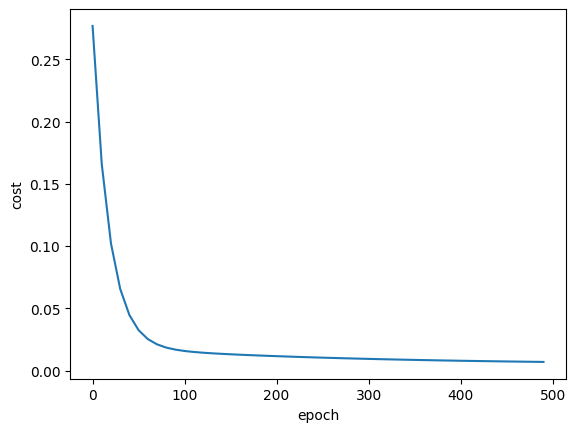

In [25]:
from matplotlib import pyplot as plt
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list,cost_list)

In [26]:
def predict(area,bedrooms,w,b):
  sclaed_x = sx.transform([[area,bedrooms]])[0]
  sclaed_price = w[0] * sclaed_x[0] + w[1] * sclaed_x[1] + b
  return sy.inverse_transform([[sclaed_price]])[0][0]

predict(2600,4,w,b)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(128.45484403267596)

In [27]:
predict(1000,2,w,b)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(30.253094462442363)

In [28]:
import random

def stochastic_gradient_descent(x,y_true,epochs,learning_rate=0.01):

  number_of_features = x.shape[1]

  w = np.ones(shape=number_of_features)
  b = 0
  total_samples = x.shape[0]

  cost_list = []
  epoch_list = []

  for i in range(epochs):
    random_index = random.randint(0,total_samples-1)
    sample_x = x[random_index]
    sample_y = y_true[random_index]
    y_predicted = np.dot(w,sample_x.T) + b

    w_grad = -(2/total_samples)*(sample_x.T.dot(sample_y-y_predicted))
    b_grad = -(2/total_samples)*(sample_y-y_predicted)

    w = w - learning_rate*w_grad
    b = b - learning_rate*b_grad

    cost = np.square(sample_y - y_predicted)

    if i%100==0:
      cost_list.append(cost)
      epoch_list.append(i)

  return w,b,cost,cost_list,epoch_list

In [29]:
w_sgd,b_sgd,cost_sgd,cost_list_sgd,epoch_list_sgd = stochastic_gradient_descent(x_scaled,y_scaled.reshape(y_scaled.shape[0]),5000)
w_sgd,b_sgd,cost_sgd

(array([0.75903916, 0.73373469]),
 np.float64(-0.28018537356288026),
 np.float64(0.005337251789967701))

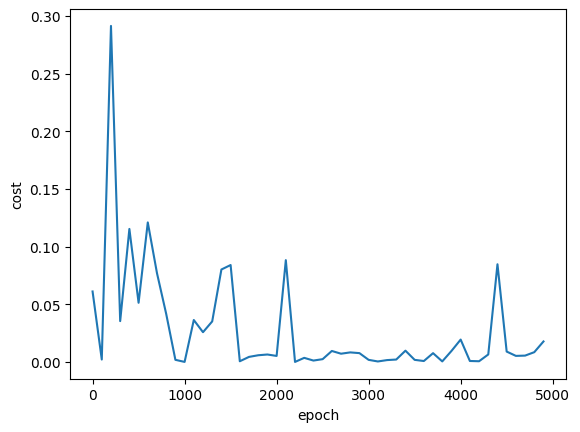

In [30]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list_sgd,cost_list_sgd)

In [65]:
predict(2600,4,w_sgd,b_sgd)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(132.0678591574883)

In [47]:
def minibatch_gradient_descent(X,y,epochs,batch_size = 5,learning_rate=0.01):
  number_of_features = X.shape[1]

  w = np.ones(shape=number_of_features)
  b = 0
  total_samples = X.shape[0]

  if(batch_size > total_samples):
    batch_size =total_samples

  cost_list = []
  epoch_list = []

  num_batches = int(total_samples/batch_size)

  for i in range(epochs):
    random_indices = np.random.permutation(total_samples)
    X_shuffled = X[random_indices]
    y_shuffled = y[random_indices]

    for j in range(0,total_samples,batch_size):
      xj = X_shuffled[j:j+batch_size]
      yj = y_shuffled[j:j+batch_size]
      # print(j,"th iteration: ", xj, yj)

      y_pred = np.dot(w,xj.T) + b

      w_grad = -(2/len(xj))*(xj.T.dot(yj-y_pred))
      b_grad = -(2/len(xj))*np.sum(yj-y_pred)

      w = w - learning_rate*w_grad
      b = b - learning_rate*b_grad

      cost = np.square(yj - y_pred)

      if i%10==0:
        cost_list.append(cost)
        epoch_list.append(i)

  return w,b,cost,cost_list,epoch_list


In [72]:
w_mbg,b_mbg,cost_mbg,cost_list_mbg,epoch_list_mbg = minibatch_gradient_descent(x_scaled,y_scaled.reshape(y_scaled.shape[0]),500,5,0.01)
w_mbg,b_mbg,cost_mbg

(array([0.67117603, 0.53357678]),
 np.float64(-0.14363746228438992),
 array([3.54475728e-03, 2.93760542e-04, 7.34400472e-03, 3.71101697e-03,
        9.02142087e-05]))

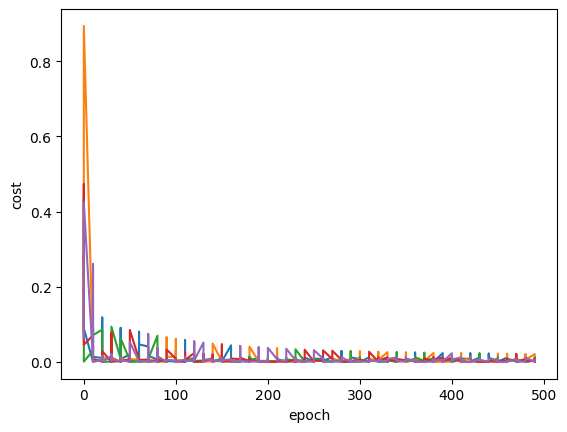

In [73]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list_mbg,cost_list_mbg)

In [76]:
predict(2770,3,w_mbg,b_mbg)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(110.17684582417996)